In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [38]:
ticker = "META"
train_df = yfinance.download(ticker, '2020-01-01', '2026-01-01')
val_df = yfinance.download(ticker, '2026-01-01')

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [39]:
val_df

Price,Close,High,Low,Open,Volume
Ticker,META,META,META,META,META
Date,,,,,
2026-01-02,649.251831,663.206979,642.354162,661.549901,13726500
2026-01-05,657.616943,663.356705,646.596623,649.850828,12213700
2026-01-06,659.443665,664.334964,650.739221,658.395546,11074400
2026-01-07,647.534912,657.976308,643.661816,654.472549,12846300
2026-01-08,644.909607,645.947733,634.587992,644.729935,11921700
...,...,...,...,...,...
2026-08-21,549.900024,553.869995,543.229980,546.890015,13848000
2026-08-24,559.020020,561.419983,546.299988,550.200012,12990600


<Axes: xlabel='Date'>

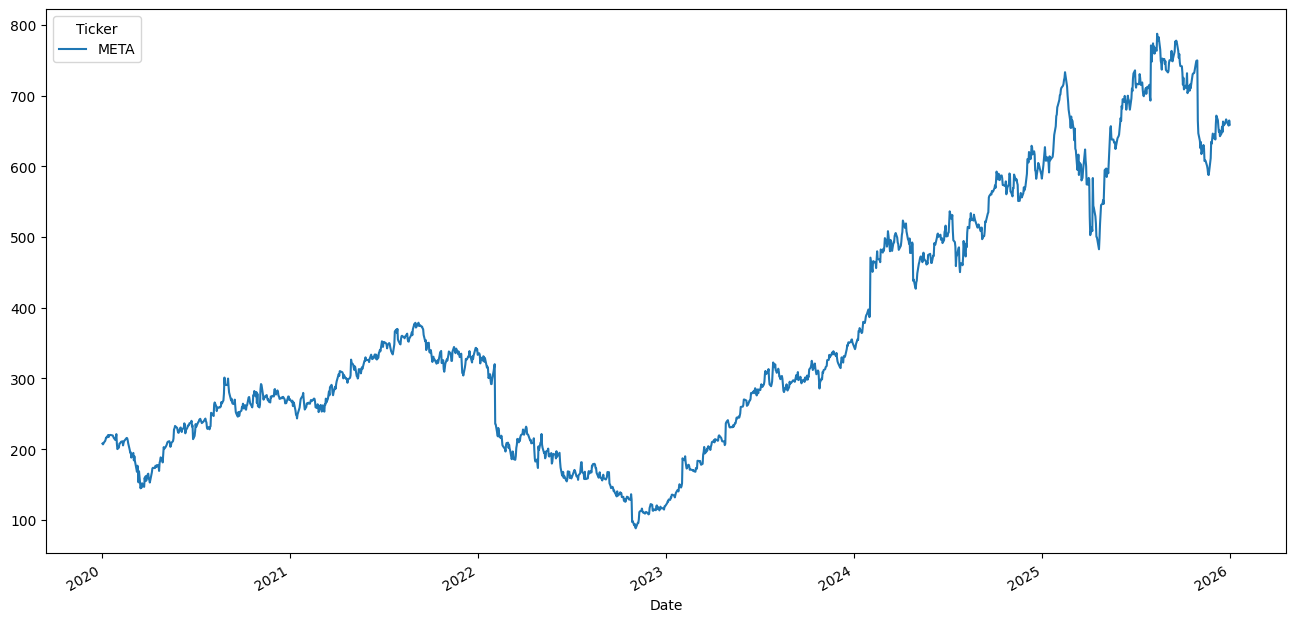

In [40]:
train_df.Close.plot(figsize=(16, 8))

In [41]:
scaler = StandardScaler()

train_df['Close'] = scaler.fit_transform(train_df['Close'])
val_df['Close'] = scaler.transform(val_df['Close'])

In [42]:
train_df.Close

Ticker,META
Date,
2020-01-02,-0.844776
2020-01-03,-0.850888
2020-01-06,-0.829248
2020-01-07,-0.826715
2020-01-08,-0.814821
...,...
2025-12-24,1.701561
2025-12-26,1.677940
2025-12-29,1.652434


In [43]:
batch_size = 30

train_data = []
val_data = []

for i in range(len(train_df) - batch_size):
    train_data.append(train_df.Close[i: i+batch_size])

for i in range(len(val_df) - batch_size):
    val_data.append(val_df.Close[i: i+batch_size])
    
train_data = np.array(train_data)
val_data = np.array(val_data)

In [44]:
train_data.shape

(1478, 30, 1)

In [51]:
X_train = torch.from_numpy(train_data[:, : -1, :])
X_test = torch.from_numpy(val_data[:, : -1, :])

y_train = torch.from_numpy(train_data[:, -1, :])
y_test = torch.from_numpy(val_data[:, -1, :])

In [57]:
y_train.shape

torch.Size([1478, 1])